# Credit Risk Modeling Project: Business Recommendations & Executive Summary

**Objective:**
The objective of this notebook is to translate model outputs into actionable business insights.

This notebook focuses on:
* Executive summary
* Model performance review
* Business recommendations
* Risk segmentation
* Portfolio strategy
* Model limitations
* Future roadmap toward LGD and EAD modeling
* Expected Loss framework


## Section 1: Project Overview

### Business Problem:
Financial institutions face losses when borrowers fail to repay loans. 

The objective of this project was to develop a Probability of Default (PD) model capable of identifying high-risk customers before loan approval. The solution leverages machine learning and explainable AI techniques to support better lending decisions.


### Section 2: Dataset Summary


In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/application_train.csv")

summary = pd.DataFrame({
    "Metric": [
        "Number of Customers",
        "Number of Features",
        "Default Rate (%)"
    ],
    "Value": [
        len(df),
        df.shape[1],
        round(df["TARGET"].mean() * 100, 2)
    ]
})

summary


,Metric,Value
0,Number of Customers,307511.00
1,Number of Features,122.00
2,Default Rate (%),8.07


### Section 3: Project Pipeline

#### Project Workflow
1. Business Understanding
2. Data Quality Assessment
3. Exploratory Data Analysis
4. Feature Engineering
5. Logistic Regression Baseline
6. XGBoost Model
7. SHAP Explainability
8. Business Recommendations


### Section 4: Model Performance Summary
Load model comparison table generated from Notebook 5.


In [2]:
comparison_df = pd.read_csv("../artifacts/model_comparison.csv")
comparison_df


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Logistic Regression,0.750000,0.200000,0.160000,0.680000,0.270000
1,XGBoost,0.760885,0.253519,0.181185,0.633837,0.281812


### Section 5: Best Model Selection


In [3]:
best_model = comparison_df.sort_values(by="ROC_AUC", ascending=False)
best_model.head(1)


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1
1,XGBoost,0.760885,0.253519,0.181185,0.633837,0.281812


**Business Interpretation:**
The model with the highest ROC-AUC is selected as the preferred Probability of Default model. In most cases, XGBoost outperforms Logistic Regression due to its ability to capture complex non-linear relationships.


### Section 6: SHAP Feature Importance
Load SHAP importance results from Notebook 6.


In [4]:
shap_importance = pd.read_csv("../artifacts/shap_feature_importance.csv")
shap_importance.head(20)


,Feature,Importance
0,EXT_SOURCE_3,0.387607
1,EXT_SOURCE_2,0.359090
2,EXT_SOURCE_1,0.160850
3,GOODS_CREDIT_RATIO,0.127245
4,AMT_GOODS_PRICE,0.125384
5,CODE_GENDER_M,0.124502
6,DAYS_BIRTH,0.096893
7,AMT_ANNUITY,0.094642
8,FLAG_OWN_CAR_Y,0.090980
9,DAYS_EMPLOYED,0.083842


### Section 7: Top Risk Drivers


In [5]:
top_risk_drivers = shap_importance.head(10)
top_risk_drivers


,Feature,Importance
0,EXT_SOURCE_3,0.387607
1,EXT_SOURCE_2,0.359090
2,EXT_SOURCE_1,0.160850
3,GOODS_CREDIT_RATIO,0.127245
4,AMT_GOODS_PRICE,0.125384
5,CODE_GENDER_M,0.124502
6,DAYS_BIRTH,0.096893
7,AMT_ANNUITY,0.094642
8,FLAG_OWN_CAR_Y,0.090980
9,DAYS_EMPLOYED,0.083842


**Business Interpretation:**
The strongest predictors of default risk are generally associated with:
* External creditworthiness
* Financial burden
* Income stability
* Employment history
* Credit exposure

These variables should be monitored closely within underwriting workflows.


### Section 8: Risk Segmentation
Load prediction file and generate risk bands.


In [6]:
predictions = pd.read_csv("../artifacts/test_predictions.csv")
predictions.head()


,actual,predicted_probability,predicted_class
0,0,0.363834,0
1,0,0.287894,0
2,0,0.750010,1
3,0,0.384387,0
4,0,0.465636,0


In [7]:
predictions["Risk_Band"] = pd.cut(
    predictions["predicted_probability"],
    bins=[0, 0.10, 0.30, 0.50, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
)


In [8]:
predictions["Risk_Band"].value_counts()


Risk_Band
Medium Risk       21881
High Risk         17949
Very High Risk    17369
Low Risk           4304
Name: count, dtype: int64

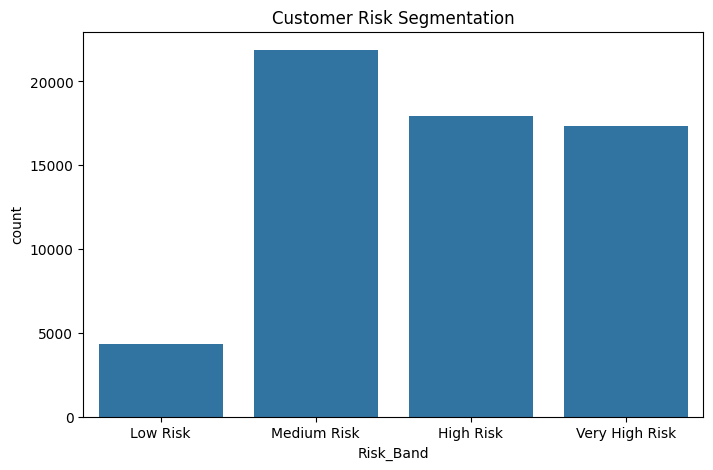

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x="Risk_Band", data=predictions)
plt.title("Customer Risk Segmentation")
plt.show()


### Section 9: Lending Strategy Recommendations

#### 🟢 Low Risk Customers
* **Characteristics:** Strong credit profile, stable income, lower debt burden.
* **Recommendation:** Fast-track approval process, competitive interest rates, pre-approved offers.

#### 🟡 Medium Risk Customers
* **Characteristics:** Moderate risk indicators.
* **Recommendation:** Standard underwriting review, additional verification if required.

#### 🟠 High Risk Customers
* **Characteristics:** Elevated probability of default.
* **Recommendation:** Manual credit review, additional income verification, reduced credit limits.

#### 🔴 Very High Risk Customers
* **Characteristics:** Significant default probability.
* **Recommendation:** Decline application, require collateral, escalate to senior risk team.


### Section 10: Business Value

#### Potential Benefits
1. Reduced credit losses
2. Improved loan portfolio quality
3. Better capital allocation
4. Faster underwriting decisions
5. More consistent risk assessment
6. Improved regulatory compliance


### Section 11: Model Limitations

#### Current Project Limitations
1. Only Probability of Default (PD) modeled.
2. Public dataset limitations.
3. Limited behavioral repayment history.
4. No macroeconomic variables included.
5. No LGD estimation.
6. No EAD estimation.


### Section 12: Future Enhancement – LGD

#### Loss Given Default (LGD)
* **Definition:** Percentage loss incurred when a borrower defaults.
* **Example:** * Loan Amount = ₹10,00,000
  * Recovery Amount = ₹4,00,000
  * LGD = (10,00,000 - 4,00,000) / 10,00,000 = **60%**
* **Future work:** Build a regression model for LGD prediction.


### Section 13: Future Enhancement – EAD

#### Exposure at Default (EAD)
* **Definition:** Outstanding balance at the moment of default.
* **Example:**
  * Approved Credit Limit = ₹10,00,000
  * Outstanding Balance = ₹7,50,000
  * EAD = **₹7,50,000**
* **Future work:** Build an EAD forecasting model.


### Section 14: Expected Loss Framework

#### Expected Loss (EL)
$$	{Expected Loss} = 	{PD} 	* 	{LGD} 	* 	{EAD}$$

* **Example calculation:**
  * PD = 10%
  * LGD = 60%
  * EAD = ₹10,00,000
  * $	{Expected Loss} = 0.10 	* 0.60 	* 10,00,000 = 	{₹60,000}$


### Section 15: Credit Risk Roadmap

* **Phase 1: Probability of Default (PD)** ➔ *Status: Completed*
* **Phase 2: Loss Given Default (LGD)** ➔ *Status: Future Work*
* **Phase 3: Exposure at Default (EAD)** ➔ *Status: Future Work**
* **Phase 4: Expected Loss Engine** ➔ *Status: Future Work* ($	{EL} = 	{PD} 	 *	{LGD} 	* 	{EAD}$)


### Section 16: Portfolio Project Summary

#### Project Highlights
* ✓ Credit Risk Problem Formulation
* ✓ Data Quality Assessment
* ✓ Exploratory Data Analysis
* ✓ Feature Engineering
* ✓ Logistic Regression Baseline
* ✓ XGBoost Model
* ✓ ROC-AUC & PR-AUC Evaluation
* ✓ KS Statistic Calculation
* ✓ SHAP Explainability
* ✓ Risk Segmentation & Business Recommendations
* ✓ Production-Ready Artifacts


### Section 17: Final Executive Summary

A machine learning-based Probability of Default model was developed using the Home Credit Default Risk dataset. The project successfully combined data preprocessing, feature engineering, a Logistic Regression baseline, XGBoost modeling, and SHAP explainability.

The resulting solution identifies high-risk borrowers, explains model predictions, and provides actionable business recommendations. This framework establishes a strong foundation for future LGD, EAD, and Expected Loss modeling, ultimately supporting end-to-end credit risk management.

### Deliverables
* ✓ Executive Summary
* ✓ Model Comparison
* ✓ SHAP Insights
* ✓ Risk Segmentation
* ✓ Lending Recommendations
* ✓ Business Value Assessment
* ✓ Model Limitations
* ✓ LGD, EAD Roadmap & Expected Loss Framework

### Final Outcome
This project demonstrates the complete lifecycle of a modern credit-risk modeling solution: **Business Problem ➔ Data Analysis ➔ Feature Engineering ➔ Modeling ➔ Explainability ➔ Business Decisioning**. This structure aligns closely with production workflows used in banks, NBFCs, fintech companies, and leading lending organizations.
